# The CEM Hopf Algebra

This notebook showcases the **Calaque-Ebrahimi-Fard-Manchon (CEM)** Hopf algebra, as implemented in the `kauri` Python package.

The CEM Hopf algebra is a Hopf algebra structure on (non-empty) rooted trees, where the coproduct is defined by *extraction-contraction* of subtrees, in contrast to the Connes-Kreimer (BCK) coproduct which uses *admissible cuts*. The single-vertex tree (bullet) serves as the unit, not the empty tree.

**Key references:**

1. D. Calaque, K. Ebrahimi-Fard & D. Manchon, *Two interacting Hopf algebras of trees: a Hopf-algebraic approach to composition and substitution of B-series*, Adv. Appl. Math. **47** (2011), 282--308. [arXiv:0806.2238](https://arxiv.org/abs/0806.2238)
2. D. Manchon, *Lois pre-Lie en interaction*, Comm. Algebra **39** (2011), 3662--3680. [arXiv:0811.2153](https://arxiv.org/abs/0811.2153)
3. P. Chartier, E. Hairer & G. Vilmart, *Algebraic structures of B-series*, Found. Comput. Math. **10** (2010), 407--420.

In [1]:
import kauri as kr
import kauri.cem as cem
from kauri import Tree, Map, ident, trees_of_order
from fractions import Fraction

We define the standard named trees for reference throughout this notebook.

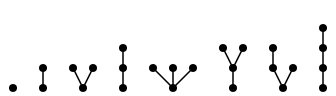

In [2]:
bullet = Tree([])            # order 1
slash  = Tree([[]])           # order 2
cherry = Tree([[], []])       # order 3, two children
chain3 = Tree([[[]]])         # order 3, chain of length 3
trident = Tree([[], [], []])  # order 4, corolla C_3
bplus_cherry = Tree([[[],[]]])  # order 4, B+(cherry)
t43     = Tree([[[]], []])    # order 4
chain4  = Tree([[[[]]]])      # order 4, chain of length 4

kr.display(bullet, slash, cherry, chain3, trident, bplus_cherry, t43, chain4)

## 1. The extraction-contraction coproduct

The CEM coproduct is defined by

$$\Delta_{\mathrm{CEM}}(\tau) = \sum_{s \subseteq \tau} s \otimes \tau \!/\! s$$

where $s$ ranges over subforests of $\tau$ and $\tau/s$ is the tree obtained by *contracting* each tree in $s$ to a single vertex. This is the extraction-contraction coproduct introduced in Calaque, Ebrahimi-Fard & Manchon (2011), Section 4.1. [arXiv:0806.2238](https://arxiv.org/abs/0806.2238)

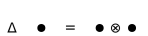

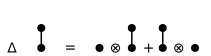

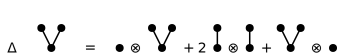

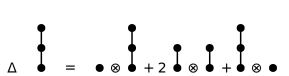

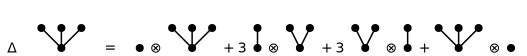

In [3]:
kr.display("Δ", bullet, "=", cem.coproduct(bullet))
kr.display("Δ", slash, "=", cem.coproduct(slash))
kr.display("Δ", cherry, "=", cem.coproduct(cherry))
kr.display("Δ", chain3, "=", cem.coproduct(chain3))
kr.display("Δ", trident, "=", cem.coproduct(trident))

### Corolla coproduct formula

**Proposition 5.1** of Calaque, Ebrahimi-Fard & Manchon (2011) states that the coproduct of the corolla $C_n$ (the tree with $n$ children at the root) satisfies the binomial formula:

$$\Delta(C_n) = \sum_{p=0}^{n} \binom{n}{p}\, C_p \otimes C_{n-p}$$

We verify this for $n = 2, 3, 4$.

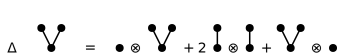

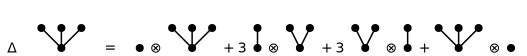

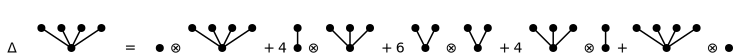

In [4]:
for n in [2, 3, 4]:
    Cn = Tree([[] for _ in range(n)])
    kr.display("Δ", Cn, "=", cem.coproduct(Cn))
    print()

### Ladder (chain) coproduct

The chains (or ladders) $\ell_n$ are the maximally tall trees of order $n$. Their coproduct structure is discussed in Section 5 of Calaque, Ebrahimi-Fard & Manchon (2011).

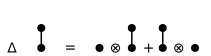

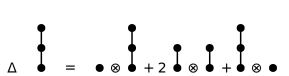

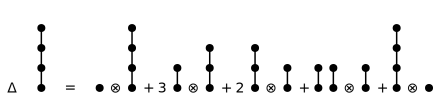

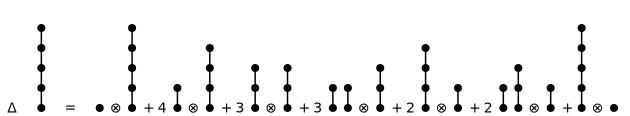

In [5]:
def chain(n):
    """Construct the chain tree of order n."""
    t = Tree([])
    for _ in range(n - 1):
        t = Tree([t.list_repr])
    return t

for n in range(2, 6):
    cn = chain(n)
    kr.display("Δ", cn, "=", cem.coproduct(cn))
    print()

## 2. Antipode

The antipode $S_{\mathrm{CEM}}$ is the convolution inverse of the identity in the CEM Hopf algebra. Since the bullet is the unit, $S(\bullet) = \bullet$.

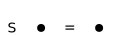

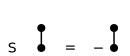

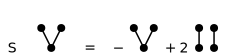

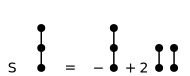

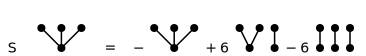

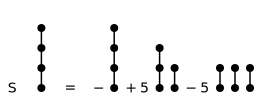

In [6]:
for t in [bullet, slash, cherry, chain3, trident, chain4]:
    kr.display("S", t, "=", cem.antipode(t))
    print()

## 3. Hopf algebra axioms

### Antipode property

The defining property of the antipode is that the CEM convolution of $S$ with the identity equals the counit composed with the unit map:

$$(S \star \mathrm{id})(\tau) = \varepsilon(\tau) \cdot \bullet$$

In `kauri`, the CEM convolution product is the `^` operator on `Map` objects. We verify this for all trees up to order 5.

In [7]:
S_star_id = cem.antipode ^ ident

for n in range(1, 6):
    for t in trees_of_order(n):
        result = S_star_id(t)
        expected = cem.counit(t) * bullet.as_forest_sum()
        assert result == expected or (result == 0 and expected == 0 * bullet.as_forest_sum()), \
            f"Failed for {t}"
    print(f"Order {n}: (S ^ id)(t) = counit(t) * bullet  ... verified")

Order 1: (S ^ id)(t) = counit(t) * bullet  ... verified
Order 2: (S ^ id)(t) = counit(t) * bullet  ... verified
Order 3: (S ^ id)(t) = counit(t) * bullet  ... verified
Order 4: (S ^ id)(t) = counit(t) * bullet  ... verified
Order 5: (S ^ id)(t) = counit(t) * bullet  ... verified


### Antipode involution: $S^2 = \mathrm{id}$

The CEM Hopf algebra is commutative (but not cocommutative), so the antipode is an involution. We verify $S(S(\tau)) = \tau$ for all trees up to order 5.

In [8]:
S_squared = cem.antipode & cem.antipode  # composition S o S

for n in range(1, 6):
    for t in trees_of_order(n):
        result = S_squared(t)
        assert result.equals(t.as_forest_sum()), f"S^2 != id for {t}"
    print(f"Order {n}: S^2 = id  ... verified")

Order 1: S^2 = id  ... verified
Order 2: S^2 = id  ... verified
Order 3: S^2 = id  ... verified
Order 4: S^2 = id  ... verified
Order 5: S^2 = id  ... verified


## 4. Substitution of B-series and modified equations

The CEM convolution product (`^`) corresponds to the *substitution law* for B-series, as shown in Chartier, Hairer & Vilmart (2010) and Calaque, Ebrahimi-Fard & Manchon (2011).

### Associativity of the CEM product

We verify $(a \star b) \star c = a \star (b \star c)$ for scalar-valued maps on trees up to order 4.

In [9]:
a = Map(lambda t: Fraction(1, t.nodes()))
b = Map(lambda t: Fraction(t.nodes(), t.factorial()))
c = Map(lambda t: Fraction(1, t.factorial()))

ab_c = (a ^ b) ^ c
a_bc = a ^ (b ^ c)

for n in range(1, 5):
    for t in trees_of_order(n):
        assert ab_c(t) == a_bc(t), f"Associativity failed for {t}"
    print(f"Order {n}: (a^b)^c = a^(b^c)  ... verified")

Order 1: (a^b)^c = a^(b^c)  ... verified
Order 2: (a^b)^c = a^(b^c)  ... verified
Order 3: (a^b)^c = a^(b^c)  ... verified
Order 4: (a^b)^c = a^(b^c)  ... verified


### The omega map (modified vector field of the Euler method)

The **omega map** is defined as the logarithm (in the CEM sense) of the Euler method's elementary weight function:

$$\omega = \log(\delta_\emptyset + \delta_\bullet)$$

where $\delta_\emptyset + \delta_\bullet$ maps the bullet to $1$ and all other trees to $0$. This is the map whose values give the coefficients of the modified equation for the explicit Euler method.

Chartier, Hairer & Vilmart (2010), p. 12, give the following closed-form results:

- **Bushy trees (corollas):** $\omega(C_n) = B_n$ (the $n$-th Bernoulli number)
- **Tall trees (chains):** $\omega(\ell_n) = \frac{(-1)^{n-1}}{n}$ (coefficients of $\log(1+x)$)

We compute $\omega$ with exact rational arithmetic using `Fraction`.

In [10]:
from kauri.cem.cem import antipode_impl as cem_antipode_impl

# Build omega with exact Fraction arithmetic
e_frac = Map(lambda x: Fraction(1, x.factorial()))
e_inv_frac = e_frac & Map(cem_antipode_impl)
delta_eb = Map(lambda x: Fraction(1) if (x == Tree(None) or x == Tree([])) else Fraction(0))
omega_frac = delta_eb ^ e_inv_frac

#### Omega values for small trees

Verified against Calaque, Ebrahimi-Fard & Manchon (2011), Section on values of $\omega$, and Chartier, Hairer & Vilmart (2010).

| Tree | $\omega(\tau)$ |
|------|---------------|
| $\bullet$ | $1$ |
| $B_+(\bullet)$ | $-1/2$ |
| cherry | $1/6$ |
| $\ell_3$ | $1/3$ |
| $C_3$ (trident) | $0$ |
| $B_+(\text{cherry})$ | $-1/6$ |
| $[\ell_2, \bullet]$ | $-1/12$ |
| $\ell_4$ | $-1/4$ |

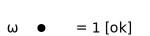

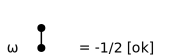

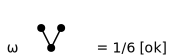

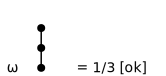

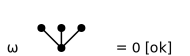

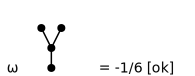

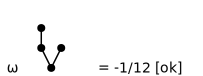

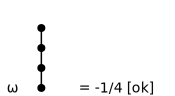

In [11]:
trees_to_check = [
    ("bullet",       bullet,       Fraction(1)),
    ("slash",        slash,        Fraction(-1, 2)),
    ("cherry",       cherry,       Fraction(1, 6)),
    ("chain3",       chain3,       Fraction(1, 3)),
    ("trident",      trident,      Fraction(0)),
    ("B+(cherry)",   bplus_cherry, Fraction(-1, 6)),
    ("t43",          t43,          Fraction(-1, 12)),
    ("chain4",       chain4,       Fraction(-1, 4)),
]

for name, t, expected in trees_to_check:
    val = omega_frac(t)
    status = "ok" if val == expected else "MISMATCH"
    kr.display("ω", t, f"= {val}  [{status}]")

#### Corollas and Bernoulli numbers

Bushy trees (corollas) $C_n$: $\omega(C_n) = B_n$ (the $n$-th Bernoulli number).

Verified against Chartier, Hairer & Vilmart (2010), p. 12.

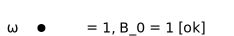

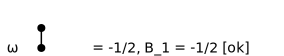

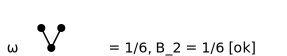

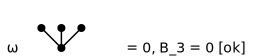

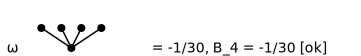

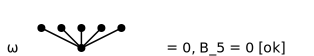

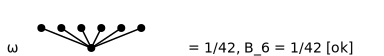

In [12]:
# Bernoulli numbers B_0, ..., B_6
bernoulli = [
    Fraction(1), Fraction(-1, 2), Fraction(1, 6), Fraction(0),
    Fraction(-1, 30), Fraction(0), Fraction(1, 42)
]

for n in range(7):
    Cn = Tree([[] for _ in range(n)])
    val = omega_frac(Cn)
    status = "ok" if val == bernoulli[n] else "MISMATCH"
    kr.display("ω", Cn, f"= {val},  B_{n} = {bernoulli[n]}  [{status}]")

#### Chains and $\log(1+x)$ coefficients

Tall trees (chains) $\ell_n$: $\omega(\ell_n) = \frac{(-1)^{n-1}}{n}$, i.e., the coefficients of the Taylor series of $\log(1+x)$.

Verified against Chartier, Hairer & Vilmart (2010), p. 12.

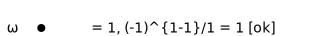

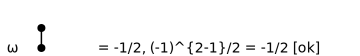

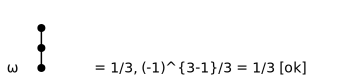

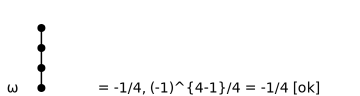

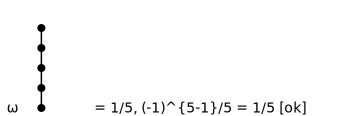

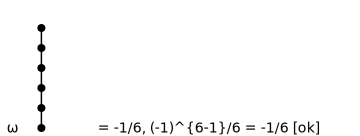

In [13]:
for n in range(1, 7):
    t = chain(n)
    val = omega_frac(t)
    expected = Fraction((-1)**(n - 1), n)
    status = "ok" if val == expected else "MISMATCH"
    kr.display("ω", t, f"= {val},  (-1)^{{{n}-1}}/{n} = {expected}  [{status}]")

## 5. Log and Exp maps

The `Map.log()` and `Map.exp()` methods implement the CEM logarithm and exponential:

$$\exp(\phi) = \phi \star e, \qquad \log(\phi) = \phi \star e^{\star(-1)}$$

where $e(\tau) = 1/\tau!$ is the elementary weights function of the exact solution and $e^{\star(-1)} = e \circ S_{\mathrm{CEM}}$.

These are mutual inverses: $\exp(\log(f)) = f$ and $\log(\exp(f)) = f$.

In [14]:
f = Map(lambda t: Fraction(1, t.nodes()))

f_exp_log = f.exp().log()
f_log_exp = f.log().exp()

for n in range(1, 5):
    for t in trees_of_order(n):
        v_orig = f(t)
        v_el = f_exp_log(t)
        v_le = f_log_exp(t)
        assert abs(v_orig - v_el) < 1e-10, f"exp(log(f)) != f for {t}"
        assert abs(v_orig - v_le) < 1e-10, f"log(exp(f)) != f for {t}"
    print(f"Order {n}: exp(log(f)) = f and log(exp(f)) = f  ... verified")

Order 1: exp(log(f)) = f and log(exp(f)) = f  ... verified
Order 2: exp(log(f)) = f and log(exp(f)) = f  ... verified
Order 3: exp(log(f)) = f and log(exp(f)) = f  ... verified
Order 4: exp(log(f)) = f and log(exp(f)) = f  ... verified
